In [1]:
from langgraph.graph import START , END , StateGraph
from typing import TypedDict , Annotated
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import BaseMessage , HumanMessage
from langgraph.graph.message import add_messages
# from langgraph.checkpoint.memory import MemorySaver

from langchain_groq import ChatGroq
from dotenv import load_dotenv
import sqlite3

In [2]:
load_dotenv()

True

In [3]:
from langgraph.prebuilt import ToolNode , tools_condition 
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool # A decorator used to mark a custom tool as a tool for the LLM
import requests

C:\Users\HP\AppData\Local\Temp\ipykernel_2840\4293398416.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import DuckDuckGoSearchRun


In [4]:
#Tools 
search_tool = DuckDuckGoSearchRun()

@tool
def calculator(first_num:float , second_num:float , operator:str):
    ''' 
    This is a calculator Tool and it takes two numbers as input and the an operator ,
    performs the required operation and returns the result.
    '''
    if operator == "+":
        result =  first_num + second_num
    
    elif operator == "-":
        result =  first_num - second_num
    
    elif operator == "*":
        result =  first_num * second_num
    
    elif operator == "/":
        if second_num == 0:
            return "Cannot divide by zero"
        result =  first_num / second_num
    
    else:
        return "Invalid operator"

    return {"first_num":first_num , "second_num":second_num , "operator":operator , "result":result}

@tool   
def stock_market_tool(symbol:str)->dict:

    ''' This is a stock market tool , provides the latest stock value of any stock .'''
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=L8FD6CO1J8UJU9V1"
    r = requests.get(url)
    data = r.json()

    return data

@tool 
def weather_api(lat:float , lon:float):
    ''' Get the current weather for a location using latitude and longitud'''
    url = f"https://api.openweathermap.org/data/2.5/weather?lat={lat}&lon={lon}&appid=83fa24fc279b921b6f04eaa973155b61"
    r = requests.get(url)
    return r.json()



In [5]:
llm = ChatGroq(
     model="openai/gpt-oss-20b",
    temperature=0.7
)

In [6]:
#Tool list - specifies all of the tools available and created by us . 
tools = [search_tool,calculator,stock_market_tool,weather_api]

#making llm aware of it 
llm_with_tool = llm.bind_tools(tools)

In [7]:
class stateSchema(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [8]:
graph = StateGraph(stateSchema)


In [9]:
def chatnode(state:stateSchema):
    """LLM node that may answer or request a tool call."""
    print(state)

    input = state['messages']
    
    res = llm_with_tool.invoke(f"answer to the users query , and if using tool , dont respond what tool is being used be professional and give smart answers by analyzing the output of the tools , {input}") # here we inovked with the llm which has the knowledge of the tools
    
    return {"messages":[res]}

Tool_Node = ToolNode(tools) # it tells the llm these are the inner available tools here 

In [10]:
#creating nodes 
graph.add_node("chatnodee",chatnode)
graph.add_node("tools", Tool_Node)

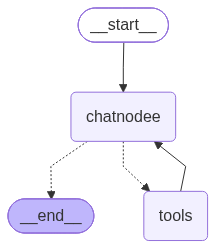

In [11]:
#adding edges to the graph

graph.add_edge(START,'chatnodee')
graph.add_conditional_edges('chatnodee',tools_condition)
graph.add_edge("tools",'chatnodee')
graph.add_edge("chatnodee",END) 

Bot = graph.compile()

Bot

In [12]:
import os 
os.environ['LANGCHAIN_PROJECT']="tools testing"

In [13]:
res = Bot.invoke({"messages": [HumanMessage(content="What is the stock price of Apple?")]})
print(res['messages'][-1].content)

{'messages': [HumanMessage(content='What is the stock price of Apple?', additional_kwargs={}, response_metadata={}, id='c82ebf9f-66c6-4ab6-81c5-32d7ec25b6c8')]}
{'messages': [HumanMessage(content='What is the stock price of Apple?', additional_kwargs={}, response_metadata={}, id='c82ebf9f-66c6-4ab6-81c5-32d7ec25b6c8'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "What is the stock price of Apple?" We need to use the stock_market_tool to get the latest stock value. Then respond professionally. Let\'s call the tool with symbol "AAPL".', 'tool_calls': [{'id': 'fc_488d6bc5-9a79-4705-9bcd-d0051b566783', 'function': {'arguments': '{"symbol":"AAPL"}', 'name': 'stock_market_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 344, 'total_tokens': 412, 'completion_time': 0.073228469, 'completion_tokens_details': {'reasoning_tokens': 43}, 'prompt_time': 0.020521895, 'prompt_tokens_details': None, 'queue_time

In [14]:
res = Bot.invoke({"messages": [HumanMessage(content="What is 2*3 ?")]})
print(res)
print(res['messages'][-1].content)

{'messages': [HumanMessage(content='What is 2*3 ?', additional_kwargs={}, response_metadata={}, id='d04bca99-1d5b-4915-addd-eb3bc0ed35b7')]}
{'messages': [HumanMessage(content='What is 2*3 ?', additional_kwargs={}, response_metadata={}, id='d04bca99-1d5b-4915-addd-eb3bc0ed35b7'), AIMessage(content='The result of\u202f\\(2 \\times 3\\)\u202fis\u202f**6**.', additional_kwargs={'reasoning_content': 'The user asks: "What is 2*3 ?" It\'s a simple multiplication. We can compute directly: 2*3 = 6. No need for tool. Provide answer.'}, response_metadata={'token_usage': {'completion_tokens': 67, 'prompt_tokens': 338, 'total_tokens': 405, 'completion_time': 0.071847186, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.274756495, 'prompt_tokens_details': {'cached_tokens': 256}, 'queue_time': 0.314681204, 'total_time': 0.346603681}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_ef00694abe', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None

In [15]:
res = Bot.invoke({"messages": [HumanMessage(content="who won the yesterdays cricket match between india and afg")]})
print(res)
print(res['messages'][-1].content)

{'messages': [HumanMessage(content='who won the yesterdays cricket match between india and afg', additional_kwargs={}, response_metadata={}, id='559abd23-6a75-46ee-bd24-c9b02cd0590f')]}
{'messages': [HumanMessage(content='who won the yesterdays cricket match between india and afg', additional_kwargs={}, response_metadata={}, id='559abd23-6a75-46ee-bd24-c9b02cd0590f'), AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer "who won the yesterdays cricket match between India and AFG". That\'s a recent event. Need current data. Use DuckDuckGo search.', 'tool_calls': [{'id': 'fc_3c18a39c-548d-4658-b2f0-f8fda2ae1176', 'function': {'arguments': '{"query":"India vs Afghanistan cricket match yesterday winner"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 68, 'prompt_tokens': 343, 'total_tokens': 411, 'completion_time': 0.108972603, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.

In [16]:
res = Bot.invoke({"messages": [HumanMessage(content="where was kalpana chawala born and what is temperature of that place right now?" \
"")]})
print(res)
print(res['messages'][-1].content)

{'messages': [HumanMessage(content='where was kalpana chawala born and what is temperature of that place right now?', additional_kwargs={}, response_metadata={}, id='51291a14-779f-495c-b48d-8e14f7452046')]}
{'messages': [HumanMessage(content='where was kalpana chawala born and what is temperature of that place right now?', additional_kwargs={}, response_metadata={}, id='51291a14-779f-495c-b48d-8e14f7452046'), AIMessage(content='', additional_kwargs={'reasoning_content': 'The user asks: "Where was Kalpana Chawla born and what is the temperature of that place right now?" We need to answer: Kalpana Chawla was born in Karnal, Haryana, India. For current temperature, we need to get current weather. We can use weather_api tool with coordinates of Karnal, Haryana. Let\'s find coordinates: Karnal is at approx 29.4°N, 76.9°E. Use weather_api.', 'tool_calls': [{'id': 'fc_91203713-48fb-4375-a657-9d63ae493fd4', 'function': {'arguments': '{"lat":29.4,"lon":76.9}', 'name': 'weather_api'}, 'type': 'f

In [17]:
url = "https://api.openweathermap.org/data/2.5/weather?lat=29.8486&lon=76.8597&appid=83fa24fc279b921b6f04eaa973155b61"
r = requests.get(url)
print(r.json())

{'coord': {'lon': 76.8597, 'lat': 29.8486}, 'weather': [{'id': 800, 'main': 'Clear', 'description': 'clear sky', 'icon': '01n'}], 'base': 'stations', 'main': {'temp': 300.64, 'feels_like': 303.19, 'temp_min': 300.64, 'temp_max': 300.64, 'pressure': 1008, 'humidity': 73, 'sea_level': 1008, 'grnd_level': 979}, 'visibility': 10000, 'wind': {'speed': 2.92, 'deg': 132, 'gust': 5.19}, 'clouds': {'all': 0}, 'dt': 1789487504, 'sys': {'country': 'IN', 'sunrise': 1789432620, 'sunset': 1789477147}, 'timezone': 19800, 'id': 1261382, 'name': 'Nīlokheri', 'cod': 200}
